# Import Library

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
import zipfile
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset

In [23]:
def load_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print('Error: Could not load image.')
        return None, None

    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    return image, gray

# Feature Extraction

In [24]:
from skimage.feature import hog

# HOG / image params
ORIENTATIONS = 9
PIXELS_PER_CELL = (8, 8)
CELLS_PER_BLOCK = (2, 2)

def extract_hog_features(image_gray):
    """
    Ekstrak fitur HOG dari gambar grayscale (sudah di-resize).
    Output: vektor HOG.
    """
    features, hog_maps = hog(
        image_gray,
        orientations=ORIENTATIONS,
        pixels_per_cell=PIXELS_PER_CELL,
        cells_per_block=CELLS_PER_BLOCK,
        block_norm='L2-Hys',
        visualize=True,
        feature_vector=True
    )
    return features, hog_maps

In [25]:
from skimage.feature import local_binary_pattern
import numpy as np

# Parameter LBP
LBP_P = 8      # jumlah sampling points
LBP_R = 1      # radius
LBP_METHOD = "uniform"   # 'default', 'ror', 'uniform', 'var'


def extract_lbp_features(image_gray):
    """
    Ekstrak fitur LBP dari gambar grayscale (sudah di-resize).
    Output:
        - feature_vector: histogram LBP sebagai vektor fitur
        - lbp_map: peta LBP (untuk visualisasi)
    """

    # Step 1: Hitung LBP map
    lbp_map = local_binary_pattern(
        image_gray,
        P=LBP_P,
        R=LBP_R,
        method=LBP_METHOD
    )

    # Step 2: Konversi LBP map → Histogram (fitur numerik)
    # jumlah bin untuk uniform LBP = P + 2
    n_bins = LBP_P + 2

    hist, _ = np.histogram(
        lbp_map.ravel(),
        bins=n_bins,
        range=(0, n_bins),
        density=True
    )

    # hist = vektor fitur (panjang kecil, contoh: 10)
    return hist, lbp_map

# Pre-processing Dataset

In [26]:
def crop_half_image(img, bottom=True):
    """
    Mengembalikan crop separuh bawah (bottom=True) atau separuh atas (bottom=False)
    img: grayscale atau BGR numpy array
    """
    h = img.shape[0]
    mid = h // 2
    if bottom:
        cropped = img[mid:, :]
    else:
        cropped = img[:mid, :]
    return cropped

In [27]:
dataset_dir = '/content/drive/MyDrive/Colab Notebooks/Klasifikasi/dataset/'
IMAGE_SIZE = (64,64)
X = []
y = []
lbp_img =[]

for root, dirs, files in os.walk(dataset_dir):
    print(root, dirs, files)
    for f in files:
        _, image_gray = load_image(os.path.join(root, f))
        img_crop = crop_half_image(image_gray, bottom=True)
        # jika crop menghasilkan area kosong atau sangat kecil, fallback ke citra penuh
        if img_crop is None or img_crop.size == 0 or img_crop.shape[0] < 4 or img_crop.shape[1] < 4:
            img_crop = image_gray  # fallback
            # optional: print warning
            print(f"[WARN] Crop menghasilkan area kecil untuk {files}, menggunakan citra penuh.")

        roi_resized = cv2.resize(img_crop, IMAGE_SIZE, interpolation=cv2.INTER_AREA) # type: ignore
        lbp_feature, lbp_maps = extract_lbp_features(roi_resized)
        if lbp_feature is None:
            continue

        lbp_img.append(lbp_maps)
        X.append(lbp_feature)

        if root.split('/')[-1]=="without_mask":
            y.append(0)

        else:
            y.append(1)

X = np.array(X)
y = np.array(y)

print(f"[INFO] Total sampel fitur: {X.shape[0]}, dimensi fitur: {X.shape[1]}")

/content/drive/MyDrive/Colab Notebooks/Klasifikasi/dataset/ ['with_mask', 'without_mask'] []
/content/drive/MyDrive/Colab Notebooks/Klasifikasi/dataset/with_mask [] ['0_0_1 copy 40.jpg', '0_0_2 copy 43.jpg', '0_0_1 copy 28.jpg', '0_0_5 copy 11.jpg', '0_0_1 copy 3.jpg', '0_0_5 copy 18.jpg', '0_0_0 copy 68.jpg', '0_0_2 copy 34.jpg', '0_0_2 copy 3.jpg', '0_0_2 copy.jpg', '0_0_0 copy 30.jpg', '0_0_0 copy 36.jpg', '0_0_1 copy 11.jpg', '0_0_1.png', '0_0_0 copy 23.jpg', '0_0_1 copy 22.jpg', '0_0_0 copy 2 2.jpg', '0_0_1 copy 2.jpg', '0_0_2 copy 16.jpg', '0_0_0 copy 20.jpg', '0_0_1 copy 9.jpg', '0_0_0 copy 74.jpg', '0_0_0 copy 19.jpg', '0_0_1 copy 23.jpg', '0_0_5 copy 7.jpg', '0_0_2 copy 31.jpg', '0_0_1 copy 19.jpg', '0_0_0 copy 6.jpg', '0_0_0 copy 29.jpg', '0_0_1 copy 32.jpg', '0_0_2 copy 11.jpg', '0_0_0.jpeg', '0_0_0 copy 9.jpg', '0_0_1 copy 16.jpg', '0_0_1 copy 36.jpg', '0_0_1 copy 20.jpg', '0_0_2.JPEG', '0_0_0 copy 65.jpg', '0_0_0 copy 57.jpg', '0_0_0 copy 5.jpg', '0_0_1 copy 46.jpg', '0_0_

# Visualisasi Features

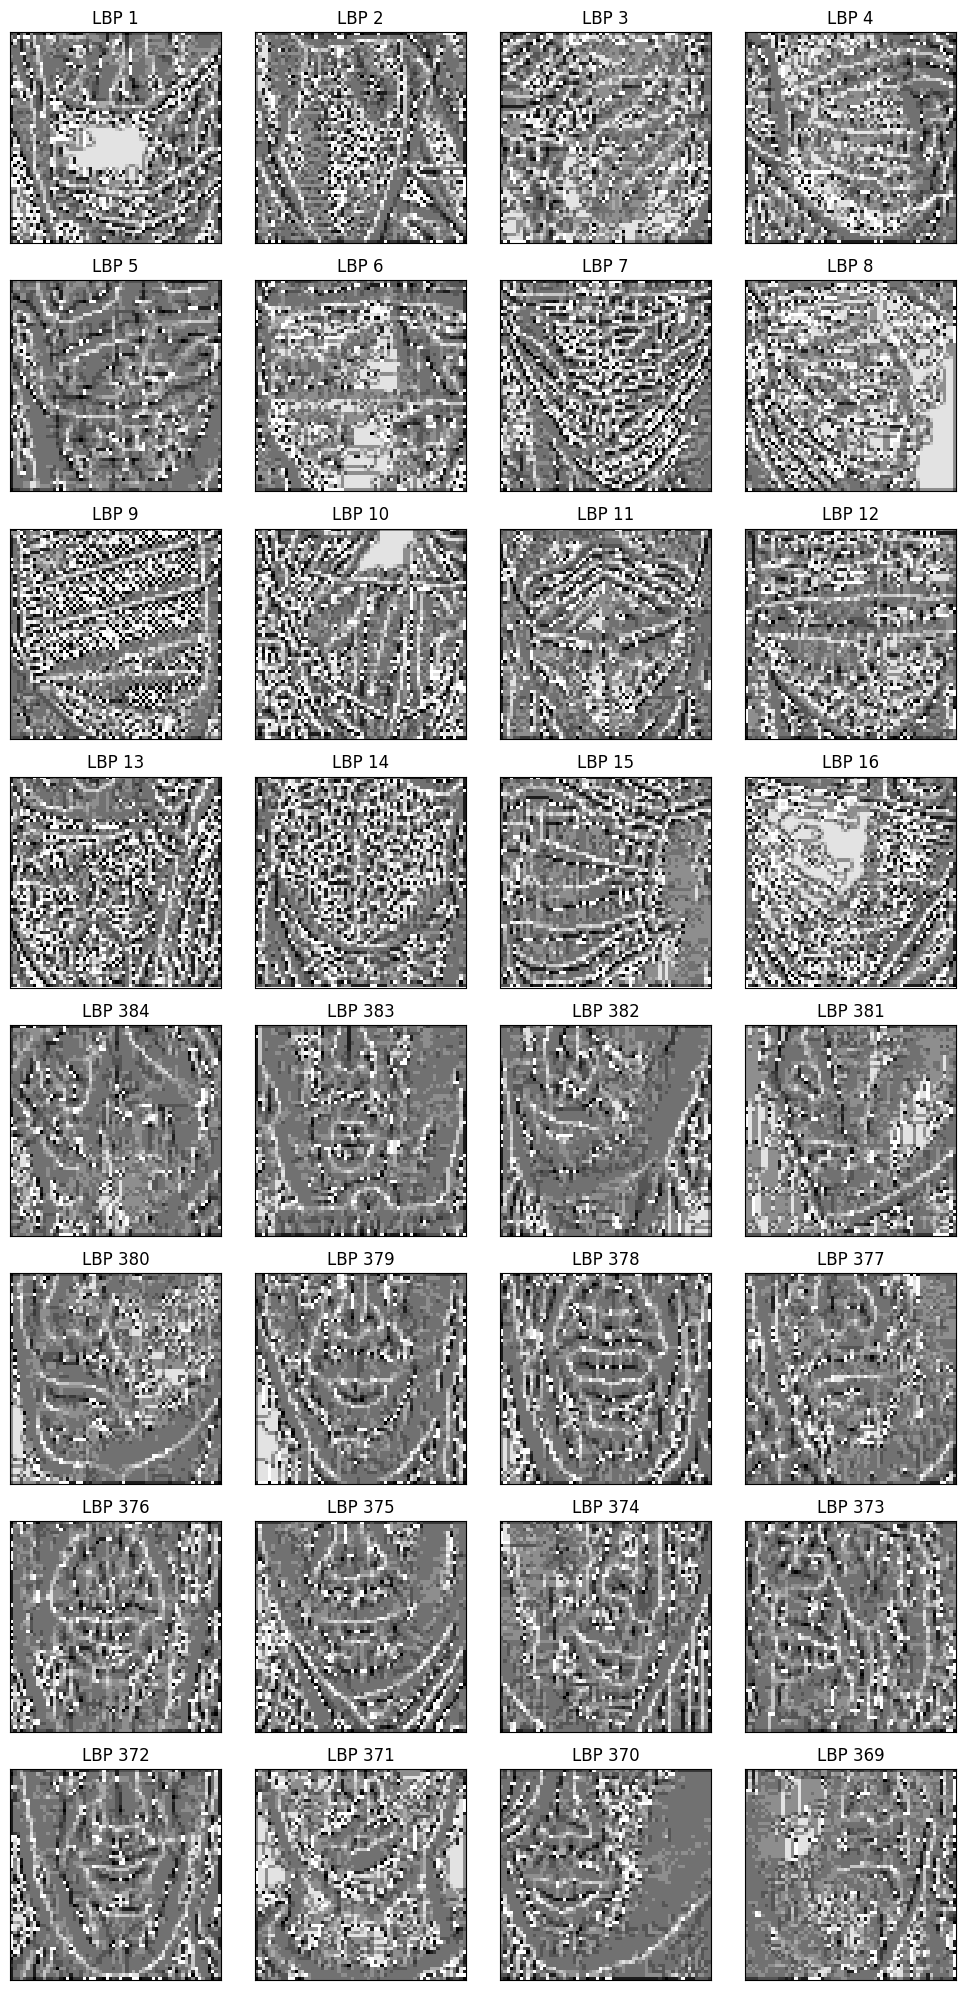

In [28]:
from skimage import exposure

ncol = 4
nrow = 8
fig, axes = plt.subplots(nrow, ncol, figsize=(10, 2.5*nrow),subplot_kw={'xticks':[], 'yticks':[]})
for i, ax in enumerate(axes.flat):
    if i < 16:
        temp = lbp_img[i]
        lbp_image = exposure.rescale_intensity(temp, in_range=(0, temp.max()))
        ax.imshow(lbp_image, cmap='gray')
        ax.set_title(f'LBP {i+1}')
    else:
        temp = lbp_img[len(lbp_img) - (i)]
        lbp_image = exposure.rescale_intensity(temp, in_range=(0, temp.max()))
        ax.imshow(lbp_image, cmap='gray')
        ax.set_title(f'LBP {len(lbp_img) - (i)}')

plt.tight_layout()
plt.show()

In [29]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y )

# Training Process

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# scale fitur
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# training SVM (RBF)
clf = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
print("[INFO] Training SVM...")
clf.fit(X_train_s, y_train)

# evaluasi
y_pred = clf.predict(X_test_s)
print("\n[RESULT] Classification report:")
print(classification_report(y_test, y_pred, target_names=["without_mask","with_mask"]))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))


[INFO] Training SVM...

[RESULT] Classification report:
              precision    recall  f1-score   support

without_mask       0.93      0.97      0.95        40
   with_mask       0.97      0.93      0.95        40

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80

Confusion matrix:
[[39  1]
 [ 3 37]]


In [31]:
import joblib

MODEL_PATH = "svm_mask_200_bottom_half.pkl"

# simpan model + scaler
joblib.dump({"model": clf,
             "scaler": scaler,
             "config": {"image_size": IMAGE_SIZE,
                        "lbp_params": {"orientations": ORIENTATIONS,
                                       "pixels_per_cell": PIXELS_PER_CELL,
                                       "cells_per_block": CELLS_PER_BLOCK},
                                        "crop": "bottom" }}, MODEL_PATH)
print(f"[INFO] Model tersimpan di: {MODEL_PATH}")

[INFO] Model tersimpan di: svm_mask_200_bottom_half.pkl


# Test Single Image

## 1. Face Detection

In [32]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [33]:
def detect_faces(image_gray, scale_factor=1.1, min_neighbors=5, min_size=(30, 30)):
    faces = face_cascade.detectMultiScale(
        image_gray,
        scaleFactor=scale_factor,
        minNeighbors=min_neighbors,
        minSize=min_size
  )
    return faces

In [34]:
def crop_faces(image_gray, faces, return_all=False):
    cropped_faces = []
    selected_faces = []
    if len(faces) > 0:
        if return_all:
            for x, y, w, h in faces:
                selected_faces.append((x, y, w, h))
                cropped_faces.append(image_gray[y:y+h, x:x+w])
        else:
            x, y, w, h = max(faces, key=lambda rect: rect[2] * rect[3])
            selected_faces.append((x, y, w, h))
            cropped_faces.append(image_gray[y:y+h, x:x+w])

    return cropped_faces, selected_faces

## 2. Feature Extraction

In [35]:
def feature_extraction_for_test(image_gray):

    features, lbp_maps = [],[]

    faces = detect_faces(image_gray)

    cropped_face, _ = crop_faces(image_gray, faces)

    if cropped_face is None:
        print("wajah tidak terdeteksi..")
        return features, lbp_maps
    else:

        img_crop = crop_half_image(cropped_face[0], bottom=True)

        # jika crop menghasilkan area kosong atau sangat kecil, fallback ke citra penuh
        if img_crop is None or img_crop.size == 0 or img_crop.shape[0] < 4 or img_crop.shape[1] < 4:
            img_crop = cropped_face[0]  # fallback
            # optional: print warning
            print(f"[WARN] Crop menghasilkan area kecil untuk {files}, menggunakan citra penuh.")

        roi_resized = cv2.resize(img_crop, IMAGE_SIZE, interpolation=cv2.INTER_AREA) # type: ignore

        features, lbo_maps = extract_lbp_features(roi_resized)
        features = np.array(features)
        features = features.reshape(1, -1)
        return features, lbp_maps

## 3. Prediction Process

In [36]:
import joblib

def predict_image(image, features, model_path):

    data = joblib.load(model_path)
    model_loaded = data.get("model")
    scaler = data.get("scaler")

    if scaler is not None:
        features = scaler.transform(features)
    pred = model_loaded.predict(features)[0]
    conf = None
    prob = 0
    prob = model_loaded.predict_proba(features)[0] if hasattr(model_loaded, "predict_proba") else None
    conf = float(max(prob))

    if pred == 1:
        label_str = "MASK"
    else:
        label_str = "NO MASK"

    print(f"Prediksi: {label_str}")

    return draw_result(image, conf, label_str)

def draw_text(image, label, score,
              font=cv2.FONT_HERSHEY_SIMPLEX,
              pos=(10, 30),
              font_scale=0.6,
              font_thickness=2,
              text_color=(255, 255, 255),
              text_color_bg=(0, 0, 255)
              ):
    x, y = pos
    score_text = f'Score: {score:.2f}'

    (w1, h1), _ = cv2.getTextSize(score_text, font, font_scale, font_thickness)
    (w2, h2), _ = cv2.getTextSize(label,      font, font_scale, font_thickness)

    box_width  = max(w1, w2) + 20
    box_height = h1 + h2 + 25

    # pastikan tidak keluar dari gambar (opsional)
    x = max(0, x)
    y = max(box_height, y)

    # background kotak
    cv2.rectangle(image,
                  (x, y - box_height),
                  (x + box_width, y),
                  text_color_bg,
                  -1)

    # tulis label
    cv2.putText(image, label, (x + 10, y - h1 - 10),
                font, font_scale, text_color, font_thickness)

    # tulis score
    cv2.putText(image, score_text, (x + 10, y - 10),
                font, font_scale, text_color, font_thickness)


def draw_result(image_bgr, score, label):
    """
    image_bgr : citra BGR (OpenCV)
    score     : float
    label     : string
    return    : citra BGR yang sudah diberi teks
    """
    result_image = image_bgr.copy()
    draw_text(result_image, label, score, pos=(10, 40))
    return result_image


Prediksi: MASK


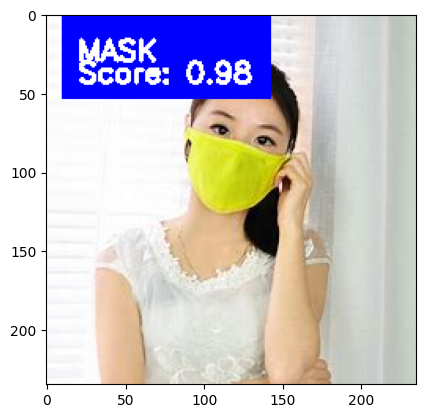

In [37]:
TESTING_IMAGE = "/content/drive/MyDrive/Colab Notebooks/Klasifikasi/testing/mask1.png"

lbp_feature, lbp_maps = [],[]
image_rgb, image_gray = load_image(TESTING_IMAGE)

lbp_feature, lbp_image = feature_extraction_for_test(image_gray)

result_image = predict_image(image_rgb, lbp_feature, MODEL_PATH)

plt.imshow(result_image)


Prediksi: MASK


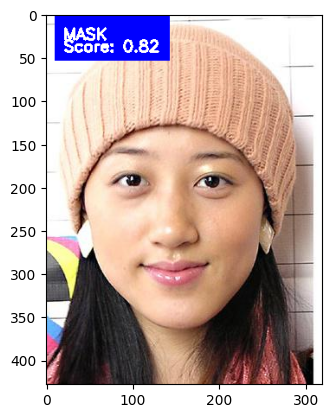

In [38]:
TESTING_IMAGE = "/content/drive/MyDrive/Colab Notebooks/Klasifikasi/testing/1.jpg"

lbp_feature, lbp_maps = [],[]
image_rgb, image_gray = load_image(TESTING_IMAGE)

lbp_feature, lbp_maps = feature_extraction_for_test(image_gray)

result_image = predict_image(image_rgb, lbp_feature, MODEL_PATH)

plt.imshow(result_image)
